# Graph Convolutional Network (GCN)

In [1]:
# Pytorch
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch.utils.data import Dataset
from torch_geometric.loader import DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

# ScikitLearn
from sklearn.preprocessing import MinMaxScaler, minmax_scale
from sklearn.metrics import classification_report

# Matplotlib
import matplotlib.pyplot as plt

# Extra utils
import pandas as pd
import numpy as np
import random

c:\Users\denni\miniconda3\envs\gcnenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Loading keypoints dataset

In [2]:
def set_seed_strict(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        
        torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)


set_seed_strict(42)

### 1.1 Read CSV

In [3]:
train_df = pd.read_csv("dataset/keypoint_train_data.csv")
validate_df = pd.read_csv("dataset/keypoint_valid_data.csv")
test_df = pd.read_csv("dataset/keypoint_test_data.csv")

In [4]:
train_df.head()

,image_id,cat_id,nose_x,nose_y,nose_v,left_eye_x,left_eye_y,left_eye_v,right_eye_x,right_eye_y,...,left_knee_v,right_knee_x,right_knee_y,right_knee_v,left_ankle_x,left_ankle_y,left_ankle_v,right_ankle_x,right_ankle_y,right_ankle_v
0,0,1,381.166412,125.746658,1.0,381.166412,114.563187,1.0,373.181763,114.563187,...,1.0,504.129974,394.948792,1.0,526.487000,553.115051,1.0,527.285461,553.115051,1.0
1,1,2,368.703186,200.296249,1.0,373.500092,186.699783,1.0,371.901123,187.499557,...,1.0,349.515381,372.251770,1.0,328.728607,556.204163,1.0,362.307220,524.212402,1.0
2,2,2,254.824997,367.375610,1.0,227.677002,378.566132,1.0,227.677002,378.566132,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0
3,3,2,423.618744,145.820709,1.0,431.610840,129.045349,1.0,426.815582,129.045349,...,1.0,298.142303,403.841614,1.0,148.689423,582.778748,1.0,256.583221,536.446777,1.0
4,4,2,241.430283,215.023224,1.0,243.826614,201.425888,1.0,242.229050,203.025558,...,1.0,223.857300,387.789368,1.0,203.089233,563.754883,1.0,239.033966,539.759583,1.0


### 1.2 Data Normalisation comparison
- MinMaxScaler
- minmax_scale
- Manual normalisation (Hip Centering + Aspect Preservation)

In [ ]:
def minmax_normalise(df, variations: str, scaler=None, is_train: bool=True):

    df_normalized = df.copy()
    
    coord_cols = df_normalized.columns.drop(['image_id', 'cat_id'])

    ####################################
    # Generated from Gemini
    ####################################
    visibility_cols = [col for col in coord_cols if col.endswith('_v')]
    xy_cols = [col for col in coord_cols if not col.endswith('_v')]
    ####################################
    # End
    ####################################

    for visibility_col in visibility_cols:
        col_name = visibility_col.replace('_v', '')
        X_col = f"{col_name}_x"
        y_col = f"{col_name}_y"
        
        mask = df_normalized[visibility_col] == 0.0
        df_normalized.loc[mask, [X_col, y_col]] = np.nan
    
    
    if variations=="col_wise":
        print("Using MinMaxScaler")
        if is_train:
            scaler = MinMaxScaler()
            df_normalized[xy_cols] = scaler.fit_transform(df_normalized[xy_cols])
            
        else:
            if scaler is None:
                print("No scaler given!")
            
            df_normalized[xy_cols] = scaler.transform(df_normalized[xy_cols])
    
    # Note: minmax_scale, scaling row wise is abandon, irrelevant
    elif variations=="row_wise":
        print("Using minmax_scale")
        scaled_array = minmax_scale(df_normalized[xy_cols], axis=1)
        df_normalized[xy_cols] = scaled_array
    
    df_normalized[xy_cols] = df_normalized[xy_cols].fillna(0.0)

    if variations=="col_wise" and is_train:
        return df_normalized, scaler
    else:
        return df_normalized

In [ ]:
def manual_normalisation(df):
    df_normalized = df.copy()
    coord_cols = df_normalized.columns.drop(['image_id', 'cat_id'])

    for index, row in df_normalized.iterrows():
        raw_coords = row[coord_cols].values.astype(np.float32)
        
        tensor_coords = torch.tensor(raw_coords).view(17, 3)
        
        normalized_tensor = normalize_coco_posture_safe(tensor_coords)
        
        flat_normalized_coords = normalized_tensor.view(-1).numpy()
        
        df_normalized.loc[index, coord_cols] = flat_normalized_coords
        
    return df_normalized

def normalize_coco_posture_safe(pos_tensor):
    coordinates = pos_tensor[:, :2].clone()
    vis = pos_tensor[:, 2].clone()
    
    valid_mask = vis > 0.0 
    
    if not valid_mask.any():
        return pos_tensor
    
    l_hip_valid = valid_mask[11].item()
    r_hip_valid = valid_mask[12].item()
    
    if l_hip_valid and r_hip_valid:
        root = (coordinates[11] + coordinates[12]) / 2.0
    elif l_hip_valid:
        root = coordinates[11]
    elif r_hip_valid:
        root = coordinates[12]
    else:
        l_sho_valid = valid_mask[5].item()
        r_sho_valid = valid_mask[6].item()
        if l_sho_valid and r_sho_valid:
            root = (coordinates[5] + coordinates[6]) / 2.0
        else:
            root = torch.tensor([0.0, 0.0], device=coordinates.device)

    coordinates[valid_mask] = coordinates[valid_mask] - root

    ###############################
    # Generated from Gen AI
    ###############################
    
    min_vals = coordinates[valid_mask].min(dim=0)[0]
    max_vals = coordinates[valid_mask].max(dim=0)[0]
    
    ranges = max_vals - min_vals

    global_scale = ranges.max()
    
    coordinates[valid_mask] = coordinates[valid_mask] / (global_scale + 1e-6)
    
    final_tensor = torch.cat([coordinates, vis.unsqueeze(1)], dim=1)
    ###############################
    # End
    ###############################

    return final_tensor

In [7]:
def normalise(df, is_train:bool, type: str=None, scaler=None, variation: str=None):
    if type == "manual":
        df_normalized = manual_normalisation(df)
        return df_normalized
        
    elif type == "auto" and variation in ["row_wise", "col_wise"]:
        
        if is_train and variation == "col_wise":
            df_normalized, scaler = minmax_normalise(df=df, variations=variation, scaler=scaler, is_train=is_train)
            return df_normalized, scaler
            
        else:
            df_normalized = minmax_normalise(df=df, variations=variation, scaler=scaler, is_train=is_train)
            return df_normalized
            
    else:
        print("Unknown type or variation given.")
        raise ValueError("Normalization failed due to invalid arguments.")

In [8]:
"""

train_df_norm = normalise(train_df, is_train=False, type="manual")
validate_df_norm = normalise(validate_df, is_train=False, type="manual")
test_df_norm = normalise(test_df, is_train=False, type="manual")
"""


train_df_norm, fitted_scaler = normalise(df=train_df, is_train=True, type="auto", variation="col_wise")
validate_df_norm = normalise(df=validate_df, is_train=False, type="auto", scaler=fitted_scaler, variation="col_wise")
test_df_norm = normalise(df=test_df, is_train=False, type="auto", scaler=fitted_scaler, variation="col_wise")



"""
train_df_norm = normalise(df=train_df, is_train=False, type="auto", variation="row_wise")
validate_df_norm = normalise(df=validate_df, is_train=False, type="auto", variation="row_wise")
test_df_norm = normalise(df=test_df, is_train=False, type="auto", variation="row_wise")
"""


Using MinMaxScaler
Using MinMaxScaler
Using MinMaxScaler


'\ntrain_df_norm = normalise(df=train_df, is_train=False, type="auto", variation="row_wise")\nvalidate_df_norm = normalise(df=validate_df, is_train=False, type="auto", variation="row_wise")\ntest_df_norm = normalise(df=test_df, is_train=False, type="auto", variation="row_wise")\n'

### 1.3 Shift label from 2:1 to 0:1.

In [9]:
train_df_norm['cat_id'] = train_df_norm['cat_id'] - 1
validate_df_norm['cat_id'] = validate_df_norm['cat_id'] - 1
test_df_norm['cat_id'] = test_df_norm['cat_id'] - 1

### 1.4 Keypoints to Edge Index

In [10]:
# For mah reference:
# https://github.com/facebookresearch/Detectron/issues/640

# "keypoints": 
#  [ 
#      "1 nose", "2 left_eye", "3 right_eye", "4 left_ear", "5 right_ear", "6 left_shoulder", "7 right_shoulder", 
#      "8 left_elbow", "9 right_elbow", "10 left_wrist", "11 right_wrist", "12 left_hip", "13 right_hip", 
#      "14 left_knee", "15 right_knee", "16 left_ankle", "17 right_ankle" 
#  ]
skeleton_edges = [
    [0, 1], [0, 2], [1, 2], [1, 3], [2, 4], [3, 5], [4, 6], [5,6], [5, 7], 
    [5, 11], [6, 12], [6, 8], [7, 9], [8, 10], [11, 12], [13, 11], 
    [14, 12], [15, 13], [16, 14]
]

source = []
target = []

for edge in skeleton_edges:
    source.append(edge[0])
    target.append(edge[1])

####################################
# Generated from Gemini
####################################

bidirection_source = source + target
bidirection_target = target + source

####################################
# End
####################################

print("Source nodes:", bidirection_source)
print("Target nodes:", bidirection_target)

edge_indexs = torch.tensor([bidirection_source, bidirection_target], dtype=torch.long)
print(edge_indexs)

Source nodes: [0, 0, 1, 1, 2, 3, 4, 5, 5, 5, 6, 6, 7, 8, 11, 13, 14, 15, 16, 1, 2, 2, 3, 4, 5, 6, 6, 7, 11, 12, 8, 9, 10, 12, 11, 12, 13, 14]
Target nodes: [1, 2, 2, 3, 4, 5, 6, 6, 7, 11, 12, 8, 9, 10, 12, 11, 12, 13, 14, 0, 0, 1, 1, 2, 3, 4, 5, 5, 5, 6, 6, 7, 8, 11, 13, 14, 15, 16]
tensor([[ 0,  0,  1,  1,  2,  3,  4,  5,  5,  5,  6,  6,  7,  8, 11, 13, 14, 15,
         16,  1,  2,  2,  3,  4,  5,  6,  6,  7, 11, 12,  8,  9, 10, 12, 11, 12,
         13, 14],
        [ 1,  2,  2,  3,  4,  5,  6,  6,  7, 11, 12,  8,  9, 10, 12, 11, 12, 13,
         14,  0,  0,  1,  1,  2,  3,  4,  5,  5,  5,  6,  6,  7,  8, 11, 13, 14,
         15, 16]])


### 1.5 Dataset class

In [11]:
class KeypointDataset(Dataset):
    def __init__(self, dataframe):
        self.x = torch.tensor(dataframe.iloc[:, 2:].values, dtype=torch.float32).view(-1, 17, 3)
        self.y = torch.tensor(dataframe.iloc[:, 1], dtype=torch.float32).view(-1, 1)
        self.edge_index = edge_indexs
    
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx):
        data = Data(x=self.x[idx], edge_index=self.edge_index, y=self.y[idx])
        return data

In [12]:
train_dataset = KeypointDataset(train_df_norm)
validate_dataset = KeypointDataset(validate_df_norm)
test_dataset = KeypointDataset(test_df_norm)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
validate_loader = DataLoader(validate_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## 2. GCN Class

In [13]:
class GCN_model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(3, 8)
        self.bn1 = nn.BatchNorm1d(8)
        self.conv2 = GCNConv(8, 16)
        self.bn2 = nn.BatchNorm1d(16)
        
        self.fc1 = nn.Linear(17 * 16, 32)
        
        self.dropout = nn.Dropout(0.5)
        
        self.fc2 = nn.Linear(32, 1)

        # self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU(0.01)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.leaky_relu(self.bn1(self.conv1(x, edge_index)))
        x = self.leaky_relu(self.bn2(self.conv2(x, edge_index)))

        ####################################
        # Generated from Gemini
        ####################################
        
        x = x.view(-1, 17 * 16)

        ####################################
        # End
        ####################################
        x = self.leaky_relu(self.fc1(x))
        x = self.dropout(x)
        out = self.fc2(x)
        return out

## 3. Training Loop

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# device = torch.device('cpu')
model = GCN_model()
model = model.to(device)
print(model)

GCN_model(
  (conv1): GCNConv(3, 8)
  (bn1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GCNConv(8, 16)
  (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=272, out_features=32, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (leaky_relu): LeakyReLU(negative_slope=0.01)
)


In [15]:
max_epochs = 200
warmup_epochs = 5
patience = 30
best_val_loss = float('inf')
patience_counter = 0
checkpoint_path = "best_model.pth"

train_losses = []
val_losses = []
train_accs = [] 
val_accs = []

loss_function = nn.BCEWithLogitsLoss()

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-2)

warmup_scheduler = LinearLR(optimizer, start_factor=0.1, total_iters=warmup_epochs)

decay_scheduler = CosineAnnealingLR(optimizer, T_max=(max_epochs - warmup_epochs), eta_min=1e-6)

scheduler = SequentialLR(
    optimizer, 
    schedulers=[warmup_scheduler, decay_scheduler], 
    milestones=[warmup_epochs]
)

for epoch in range(max_epochs):
    
    model.train()
    running_train_loss = 0.0
    train_correct = 0

    for batch_data in train_loader:
        
        batch_data = batch_data.to(device)
        optimizer.zero_grad()
        out = model(batch_data)
        
        loss = loss_function(out, batch_data.y.view(-1,1))
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * batch_data.num_graphs
        probs = torch.sigmoid(out)
        preds = (probs > 0.5).float()
        train_correct += (preds == batch_data.y.view(-1,1)).sum().item()

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = train_correct / len(train_loader.dataset)

    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    
    with torch.no_grad():
        for batch_data in validate_loader:
            batch_data = batch_data.to(device)
            
            out = model(batch_data)
            loss = loss_function(out, batch_data.y.view(-1,1))
            
            running_val_loss += loss.item() * batch_data.num_graphs
            probs = torch.sigmoid(out)
            preds = (probs > 0.5).float()
            val_correct += (preds == batch_data.y.view(-1,1)).sum().item()

    epoch_val_loss = running_val_loss / len(validate_loader.dataset)
    epoch_val_acc = val_correct / len(validate_loader.dataset)
    
    print(f"Epoch {epoch+1:03d}/{max_epochs} | LR: {current_lr:.6f} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
    
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)

    if epoch_val_loss < best_val_loss:
        print(f"Loss improved from {best_val_loss:.4f} to {epoch_val_loss:.4f}. Saving checkpoint!")
        best_val_loss = epoch_val_loss
        patience_counter = 0
        
        torch.save(model.state_dict(), checkpoint_path)
        
    else:
        patience_counter += 1
        print(f"Patience: {patience_counter}/{patience}")
        
        if patience_counter >= patience:
            print(f"Early Stopping triggered")
            break

print("Training Complete.")

Epoch 001/200 | LR: 0.000280 | Train Loss: 0.6914 | Val Loss: 0.6864
Loss improved from inf to 0.6864. Saving checkpoint!
Epoch 002/200 | LR: 0.000460 | Train Loss: 0.6714 | Val Loss: 0.6650
Loss improved from 0.6864 to 0.6650. Saving checkpoint!
Epoch 003/200 | LR: 0.000640 | Train Loss: 0.6469 | Val Loss: 0.6421
Loss improved from 0.6650 to 0.6421. Saving checkpoint!
Epoch 004/200 | LR: 0.000820 | Train Loss: 0.6280 | Val Loss: 0.6303
Loss improved from 0.6421 to 0.6303. Saving checkpoint!
Epoch 005/200 | LR: 0.001000 | Train Loss: 0.6140 | Val Loss: 0.6121
Loss improved from 0.6303 to 0.6121. Saving checkpoint!
Epoch 006/200 | LR: 0.001000 | Train Loss: 0.5988 | Val Loss: 0.5958
Loss improved from 0.6121 to 0.5958. Saving checkpoint!
Epoch 007/200 | LR: 0.001000 | Train Loss: 0.5896 | Val Loss: 0.5864
Loss improved from 0.5958 to 0.5864. Saving checkpoint!
Epoch 008/200 | LR: 0.000999 | Train Loss: 0.5792 | Val Loss: 0.5753
Loss improved from 0.5864 to 0.5753. Saving checkpoint!
Epo

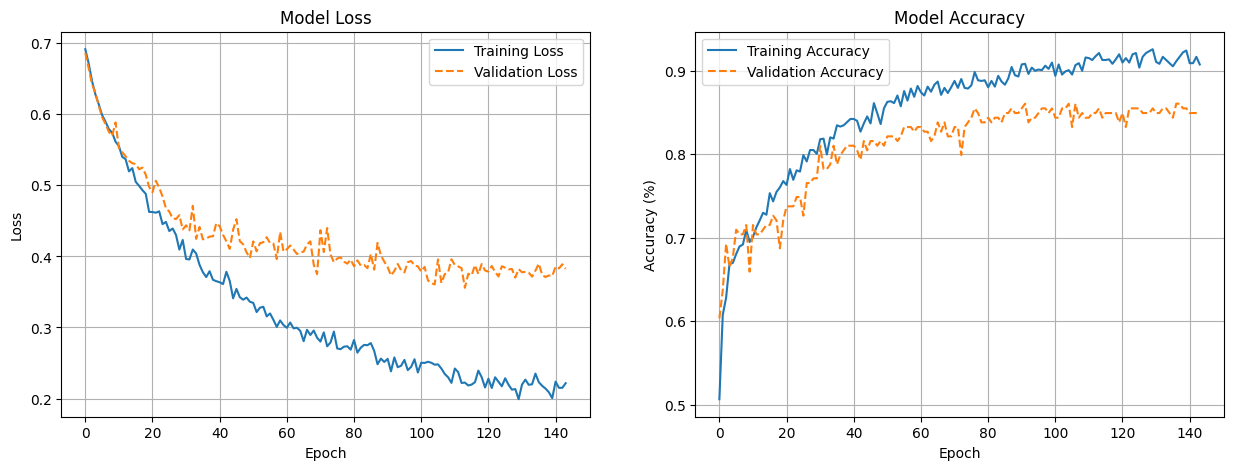

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(train_losses, label='Training Loss')
ax1.plot(val_losses, label='Validation Loss', linestyle='--')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs, label='Training Accuracy')
ax2.plot(val_accs, label='Validation Accuracy', linestyle='--')
ax2.set_title('Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.show()

In [17]:
model.load_state_dict(torch.load(checkpoint_path))
model.eval() 

final_preds = []
final_true = []

with torch.no_grad():
    for batch_data in test_loader:
        batch_data = batch_data.to(device)
        
        out = model(batch_data)
        
        probs = torch.sigmoid(out)
        preds = (probs > 0.5).float()
        
        final_preds.extend(preds.cpu().numpy())
        final_true.extend(batch_data.y.cpu().numpy())


print(classification_report(final_true, final_preds, target_names=["Good Posture", "Bad Posture"], zero_division=0))

              precision    recall  f1-score   support

Good Posture       0.73      0.88      0.80        41
 Bad Posture       0.88      0.73      0.80        48

    accuracy                           0.80        89
   macro avg       0.80      0.80      0.80        89
weighted avg       0.81      0.80      0.80        89

